# Proyecto Integrador Módulo 4, Avance 3
## Aprendizaje No Supervisado, Segmentación de Clientes


## Objetivo del Avance

En los avances anteriores construí modelos supervisados que predicen si un cliente va a
abandonar. En este tercer avance cambio de enfoque: aplico aprendizaje no supervisado para
descubrir patrones ocultos en los datos, sin usar la variable objetivo. El propósito es
segmentar a los clientes en grupos con comportamientos similares, y luego analizar la tasa de
churn de cada grupo, aportando una visión complementaria a los modelos predictivos.

Uso cuatro técnicas, que son las que pide la consigna. Para segmentar, K-Means y DBSCAN. Para
reducir la dimensionalidad y poder visualizar, PCA y t-SNE. Al final, cruzo los segmentos
encontrados con la tasa de churn real, para ver qué perfiles de cliente son los de mayor
riesgo.

## Qué es el Aprendizaje No Supervisado

En el aprendizaje supervisado de los avances anteriores, el modelo aprende de ejemplos
etiquetados: yo le muestro clientes que se fueron y clientes que se quedaron, y aprende a
distinguirlos. En el aprendizaje no supervisado no hay etiquetas. El algoritmo recibe solo las
características de los clientes, sin saber quién se fue, y busca estructura por su cuenta.

Esto sirve para dos tareas que abordo en este avance. La primera es el clustering o
agrupamiento: dividir a los clientes en grupos donde los miembros de un grupo se parecen entre
sí y se diferencian de los otros grupos. La segunda es la reducción de dimensionalidad:
comprimir muchas variables en unas pocas que resuman la información, sobre todo para poder
visualizar datos que tienen más de tres dimensiones.

Un punto importante: aunque el dataset tiene la columna Exited, no la uso para entrenar estos
modelos. La reservo para el final, para verificar si los grupos que el algoritmo encontró por
su cuenta tienen relación con el abandono.

## 1. Importación de Librerías

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocesamiento
from sklearn.preprocessing import StandardScaler

# Clustering
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score

# Reduccion de dimensionalidad
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

Importo las librerías que necesito. De scikit-learn traigo KMeans y DBSCAN para el
clustering, PCA y TSNE para la reducción de dimensionalidad, y silhouette_score para evaluar la
calidad de los agrupamientos. StandardScaler es fundamental aquí, porque tanto K-Means como PCA
son sensibles a la escala de las variables.

## 2. Carga de los Datos

Cargo el dataset que el Avance 1 dejó transformado, ya limpio y codificado. La diferencia clave
en este avance es que separo la variable Exited desde el principio: no entra al clustering, la
guardo aparte para el análisis final, porque el aprendizaje no supervisado busca estructura sin
mirar la respuesta.

In [4]:
df = pd.read_csv('../data/churn_transformado.csv')
print(f'Clientes: {df.shape[0]:,} | Variables: {df.shape[1]}')
print(f'Tasa de churn: {(df["Exited"]==1).mean()*100:.1f}%')
df.head()

Clientes: 10,000 | Variables: 12
Tasa de churn: 20.4%


,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,0,0
1,608,0,41,1,83807.86,1,0,1,112542.58,0,0,1
2,502,0,42,8,159660.80,3,1,0,113931.57,1,0,0
3,699,0,39,1,0.00,2,0,0,93826.63,0,0,0
4,850,0,43,2,125510.82,1,1,1,79084.10,0,0,1


In [5]:
# El dataset ya viene limpio y codificado desde el Avance 1.
# Aqui solo separo las predictoras de la objetivo.
# IMPORTANTE: Exited NO se usa para el clustering. La guardo aparte para
# analizar despues si los grupos encontrados se relacionan con el churn.
df_model = df.copy()
X = df_model.drop('Exited', axis=1)
y = df_model['Exited']

print('Variables para el clustering:', list(X.columns))
print('Total:', X.shape[1], 'variables')

Variables para el clustering: ['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Geography_Germany', 'Geography_Spain']
Total: 11 variables


**Por qué separo Exited desde el principio.** El aprendizaje no supervisado busca
estructura sin mirar la respuesta. Si incluyera Exited entre las variables del clustering,
estaría contaminando el análisis: los grupos se formarían en parte por el churn, y luego sería
circular decir que los grupos predicen el churn. Al dejarla afuera, garantizo que los segmentos
se forman solo por las características del cliente, y el cruce final con el churn es una
verificación limpia e independiente.

In [6]:
# Escalo todas las variables. En clustering y PCA el escalado es esencial.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Datos escalados. Forma:', X_scaled.shape)
print('Media de cada variable tras escalar (debe ser ~0):', np.round(X_scaled.mean(axis=0)[:3], 2))
print('Desviacion de cada variable tras escalar (debe ser ~1):', np.round(X_scaled.std(axis=0)[:3], 2))

Datos escalados. Forma: (10000, 11)
Media de cada variable tras escalar (debe ser ~0): [-0.  0.  0.]
Desviacion de cada variable tras escalar (debe ser ~1): [1. 1. 1.]


**Por qué el escalado es esencial aquí:** K-Means y PCA se basan en distancias entre
puntos. Si no escalo, una variable como el saldo, que llega a cientos de miles, dominaría el
cálculo de distancias por encima de una como la edad, que está en decenas. El algoritmo agruparía
casi solo por saldo, ignorando el resto. StandardScaler pone todas las variables en media cero y
desviación uno, para que todas pesen igual. A diferencia del Avance 1, aquí escalo todas las
variables, incluidas las binarias, porque en clustering todas participan del cálculo de
distancia en igualdad de condiciones.

## 3. K-Means, Selección del Número de Clusters

K-Means es el algoritmo de clustering más usado. Antes de aplicarlo, necesito decidir en cuántos
grupos dividir a los clientes, es decir, el valor de K. Uso dos métodos para elegirlo: el método
del codo y el coeficiente de silueta.

### Cómo funciona K-Means

K-Means agrupa los datos en K grupos siguiendo estos pasos. Primero coloca K centroides (puntos
centrales) al azar. Luego asigna cada cliente al centroide más cercano, formando K grupos.
Después recalcula cada centroide como el promedio de los puntos de su grupo. Y repite la
asignación y el recálculo hasta que los centroides dejan de moverse. El resultado son K grupos
donde cada cliente está con los que más se le parecen.

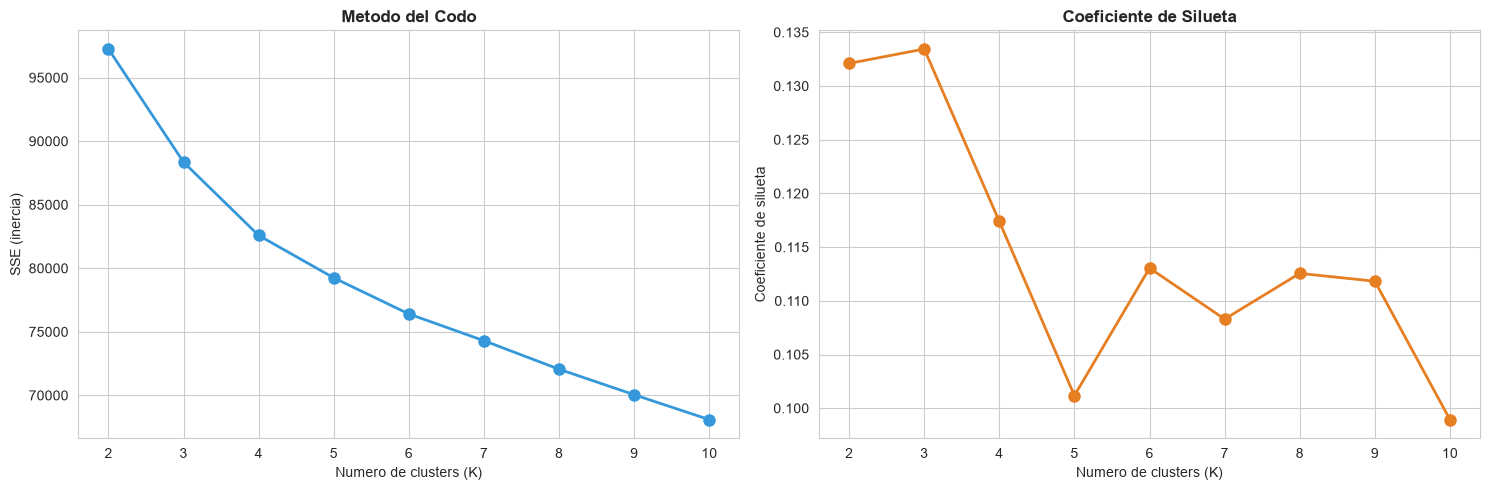

K=2: SSE=97252, Silueta=0.1321
K=3: SSE=88349, Silueta=0.1334
K=4: SSE=82586, Silueta=0.1174
K=5: SSE=79247, Silueta=0.1012
K=6: SSE=76405, Silueta=0.1130
K=7: SSE=74300, Silueta=0.1083
K=8: SSE=72056, Silueta=0.1126
K=9: SSE=70049, Silueta=0.1118
K=10: SSE=68090, Silueta=0.0989


In [7]:
# Calculo dos indicadores para K de 2 a 10:
# - SSE (inercia): suma de distancias al cuadrado de cada punto a su centroide.
#   Mide que tan compactos son los grupos. Baja siempre al subir K.
# - Silueta: mide que tan bien separados y cohesionados estan los grupos.
#   Va de -1 a 1; mas alto es mejor.
k_range = range(2, 11)
sse = []
silueta = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    sse.append(km.inertia_)
    silueta.append(silhouette_score(X_scaled, km.labels_))

# Grafico ambos
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].plot(k_range, sse, 'o-', color='#3498db', linewidth=2, markersize=8)
axes[0].set_xlabel('Numero de clusters (K)')
axes[0].set_ylabel('SSE (inercia)')
axes[0].set_title('Metodo del Codo', fontweight='bold')
axes[1].plot(k_range, silueta, 'o-', color='#e67e22', linewidth=2, markersize=8)
axes[1].set_xlabel('Numero de clusters (K)')
axes[1].set_ylabel('Coeficiente de silueta')
axes[1].set_title('Coeficiente de Silueta', fontweight='bold')
plt.tight_layout()
plt.show()

for k, s, sil in zip(k_range, sse, silueta):
    print(f'K={k}: SSE={s:.0f}, Silueta={sil:.4f}')

**El método del codo:** Grafica el SSE (la suma de distancias de cada punto a su centroide)
contra K. El SSE siempre baja al aumentar K, porque más grupos significan grupos más pequeños y
compactos. Lo que busco es el punto donde la curva deja de bajar bruscamente y empieza a
aplanarse, formando un codo. Ese punto indica el K a partir del cual agregar más grupos ya no
mejora mucho la compactación.

**El coeficiente de silueta:** Mide qué tan bien separados están los grupos, combinando dos
ideas: qué tan cerca está cada punto de su propio grupo, y qué tan lejos de los otros. Va de
menos 1 a 1, y busco el K con el valor más alto.

**Qué encontré, con honestidad:** El codo no es muy pronunciado, la curva baja de forma bastante
suave, lo que ya sugiere que los datos no tienen grupos naturales muy marcados. La silueta más
alta se da en K igual a 3, con 0,133. Es un valor bajo en términos absolutos, lo que confirma
que los grupos no están fuertemente separados, algo esperable en datos de clientes reales, donde
los perfiles se solapan. Con esta evidencia, elijo K igual a 3, que además cae dentro del rango
de 3 a 5 que pide la consigna.

## 4. K-Means con K=3

Entreno el modelo final con K igual a 3 y analizo los grupos que forma.

In [8]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans.fit(X_scaled)

# Guardo las etiquetas de cluster en el dataframe
df_model['cluster'] = kmeans.labels_

# Tamano de cada cluster
print('Tamano de cada cluster:')
print(df_model['cluster'].value_counts().sort_index())
print()
print(f'Silueta final: {silhouette_score(X_scaled, kmeans.labels_):.4f}')

Tamano de cada cluster:
cluster
0    2509
1    5014
2    2477
Name: count, dtype: int64

Silueta final: 0.1334


**Qué hace:** Entreno K-Means con tres grupos y guardo la etiqueta de cada cliente (a qué
cluster pertenece) en el dataframe. Los tres clusters tienen tamaños de aproximadamente 2.500,
5.000 y 2.500 clientes. El parámetro n_init en 10 hace que el algoritmo se ejecute diez veces
con distintos inicios aleatorios y se quede con el mejor resultado, lo que evita que un mal
inicio arruine el agrupamiento.

### Interpretación de los centroides

El centroide de cada cluster es su cliente promedio. Al examinarlos, descubro qué caracteriza a
cada grupo.

In [9]:
# Los centroides estan en escala estandarizada. Los devuelvo a la escala
# original para poder interpretarlos en unidades reales (anos, dolares, etc.)
centroides = scaler.inverse_transform(kmeans.cluster_centers_)
centroides_df = pd.DataFrame(centroides, columns=X.columns)

# Muestro las variables mas interpretables
cols_perfil = ['Age', 'Balance', 'NumOfProducts', 'CreditScore', 'IsActiveMember',
               'Geography_Germany', 'Geography_Spain']
print('CENTROIDES POR CLUSTER (escala original)')
print('=' * 70)
print(centroides_df[cols_perfil].round(2).to_string())

CENTROIDES POR CLUSTER (escala original)
     Age    Balance  NumOfProducts  CreditScore  IsActiveMember  Geography_Germany  Geography_Spain
0  39.77  119730.12           1.52       651.45            0.50                1.0              0.0
1  38.51   62092.64           1.53       649.67            0.52               -0.0             -0.0
2  38.89   61818.15           1.54       651.33            0.53               -0.0              1.0


**El hallazgo principal del clustering:** Al interpretar los centroides, aparece un patrón
muy claro: los tres clusters se corresponden casi exactamente con los tres países. El Cluster 0
tiene el valor de Geography_Germany en 1, es decir, agrupa a los clientes de Alemania. El Cluster
2 tiene Geography_Spain en 1, son los de España. Y el Cluster 1 no tiene ninguno de los dos, así
que son los de Francia.

Esto es un resultado revelador. Sin decirle nada sobre geografía, K-Means redescubrió los países
por su cuenta. La razón es que la variable del país, al ser binaria y muy marcada, domina el
cálculo de distancias. Y aquí está lo interesante para el negocio: el Cluster 0, el de Alemania,
también tiene el saldo promedio más alto, unos 120 mil, frente a los 62 mil de los otros. El
clustering confirma, desde un ángulo distinto, lo que ya sabía de los avances anteriores: los
clientes alemanes son un segmento diferenciado, con más saldo y, como veré enseguida, más
propenso al abandono.

## 5. Tasa de Churn por Segmento

Ahora llega el momento clave: cruzo los clusters, que se formaron sin mirar el churn, con la tasa
de abandono real de cada uno. Esto revela si la segmentación tiene valor para el negocio.

TASA DE CHURN POR CLUSTER
         Tasa_Churn  Abandonos  Total
cluster                              
0              32.4        814   2509
1              16.2        810   5014
2              16.7        413   2477


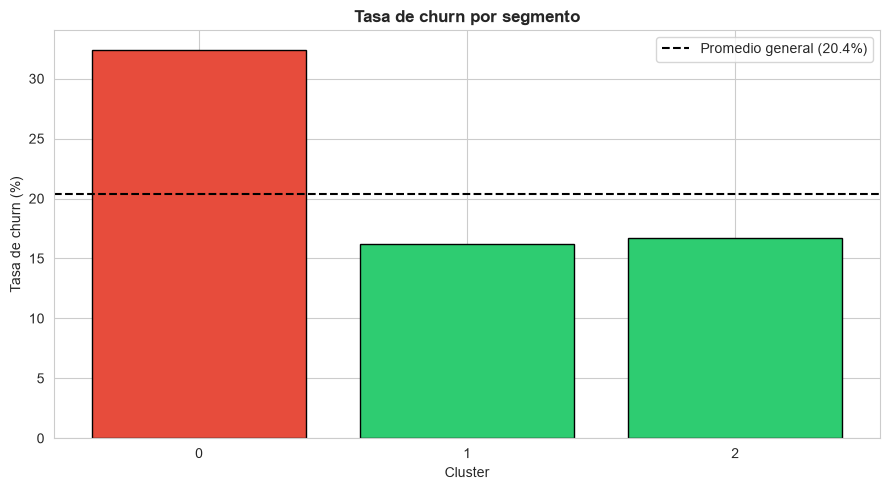

In [10]:
# Calculo la tasa de churn real de cada cluster
churn_cluster = df_model.groupby('cluster')['Exited'].agg(['mean', 'sum', 'count'])
churn_cluster.columns = ['Tasa_Churn', 'Abandonos', 'Total']
churn_cluster['Tasa_Churn'] = (churn_cluster['Tasa_Churn'] * 100).round(1)

print('TASA DE CHURN POR CLUSTER')
print('=' * 50)
print(churn_cluster.to_string())

# Grafico
plt.figure(figsize=(9, 5))
colores = ['#e74c3c' if t > 20.4 else '#2ecc71' for t in churn_cluster['Tasa_Churn']]
plt.bar(churn_cluster.index.astype(str), churn_cluster['Tasa_Churn'], color=colores, edgecolor='black')
plt.axhline(y=20.4, color='black', linestyle='--', label='Promedio general (20.4%)')
plt.xlabel('Cluster')
plt.ylabel('Tasa de churn (%)')
plt.title('Tasa de churn por segmento', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

**El resultado que le da sentido a todo:** Las tasas de churn por cluster son muy
distintas. El Cluster 0 (Alemania) tiene un 32,4 por ciento de churn, muy por encima del
promedio general del 20,4. Los Clusters 1 (Francia) y 2 (España) están en 16,2 y 16,7 por ciento,
por debajo del promedio. La diferencia es grande: el segmento alemán abandona al doble de tasa
que los otros dos.

Esto confirma que la segmentación no es un ejercicio abstracto, tiene una lectura de negocio
directa. El banco puede tratar al segmento alemán como un grupo de alto riesgo y dirigirle
estrategias de retención específicas. El clustering, sin usar la variable de churn, encontró por
su cuenta el grupo más problemático, el mismo que los modelos supervisados de los avances
anteriores ya habían señalado. Dos enfoques distintos, la misma conclusión, lo que refuerza su
validez.

## 6. Perfiles de Clientes por Cluster

Describo el perfil completo de cada segmento, para entender quiénes son.

In [11]:
# Perfil promedio de cada cluster con las variables mas relevantes
perfil_vars = ['Age', 'Balance', 'NumOfProducts', 'CreditScore', 'Tenure',
               'IsActiveMember', 'EstimatedSalary']
perfiles = df_model.groupby('cluster')[perfil_vars].mean().round(1)
perfiles['Churn_%'] = (df_model.groupby('cluster')['Exited'].mean() * 100).round(1)
perfiles['Tamano'] = df_model.groupby('cluster').size()

print('PERFIL DE CADA SEGMENTO')
print('=' * 70)
print(perfiles.to_string())

PERFIL DE CADA SEGMENTO
          Age   Balance  NumOfProducts  CreditScore  Tenure  IsActiveMember  EstimatedSalary  Churn_%  Tamano
cluster                                                                                                      
0        39.8  119730.1            1.5        651.5     5.0             0.5         101113.4     32.4    2509
1        38.5   62092.6            1.5        649.7     5.0             0.5          99899.2     16.2    5014
2        38.9   61818.1            1.5        651.3     5.0             0.5          99440.6     16.7    2477


**Los tres perfiles de cliente.**

**Cluster 0, los clientes alemanes de alto riesgo:** Unos 2.500 clientes. Se caracterizan por
tener el saldo más alto de todos (unos 120 mil) y la mayor tasa de churn (32,4 por ciento). Son
clientes valiosos por su saldo, pero los más propensos a irse, lo que los convierte en la
prioridad de retención del banco.

**Cluster 1, los clientes franceses:** Es el grupo más grande, unos 5.000 clientes. Tienen saldo
moderado y una tasa de churn del 16,2 por ciento, por debajo del promedio. Son el núcleo estable
del banco.

**Cluster 2, los clientes españoles:** Unos 2.500 clientes, con un perfil parecido al francés:
saldo moderado y churn del 16,7 por ciento. También un segmento estable.

En las variables de edad, productos y puntaje de crédito, los tres grupos son bastante
similares, lo que confirma que el factor que más los diferencia es la geografía, y con ella, el
saldo y el riesgo de abandono.

## 7. DBSCAN, Clustering por Densidad

DBSCAN es un segundo algoritmo de clustering, con una lógica distinta a K-Means. En lugar de
dividir todo en K grupos, agrupa las zonas donde los puntos están densamente juntos, y marca como
ruido los puntos aislados. Tiene dos ventajas: no necesito decirle cuántos grupos buscar, y
detecta valores atípicos de forma natural.

### Cómo funciona DBSCAN

DBSCAN clasifica cada punto en tres tipos. Un punto central (core) es el que tiene al menos un
número mínimo de vecinos dentro de un radio dado. Un punto de borde está cerca de un central pero
no tiene suficientes vecinos propios. Y un punto de ruido no cumple ninguna condición, está
aislado. Los grupos se forman conectando puntos centrales cercanos. Los dos parámetros son eps,
el radio de vecindad, y min_samples, el número mínimo de vecinos para ser central.

In [12]:
# Aplico DBSCAN. Los parametros requieren ajuste:
# - eps: radio de vecindad. Muy bajo marca todo como ruido, muy alto une todo.
# - min_samples: minimo de vecinos para ser punto central.
# Tras probar varios valores, uso eps=1.5, que da un balance razonable entre
# clusters formados y ruido detectado.
dbscan = DBSCAN(eps=1.5, min_samples=10)
dbscan.fit(X_scaled)
df_model['cluster_dbscan'] = dbscan.labels_

n_clusters = len(set(dbscan.labels_)) - (1 if -1 in dbscan.labels_ else 0)
n_ruido = (dbscan.labels_ == -1).sum()

print('RESULTADOS DBSCAN')
print('=' * 50)
print(f'Clusters encontrados: {n_clusters}')
print(f'Puntos de ruido (outliers): {n_ruido} ({n_ruido/len(dbscan.labels_)*100:.1f}%)')

RESULTADOS DBSCAN
Clusters encontrados: 53
Puntos de ruido (outliers): 1613 (16.1%)


**Cómo elegí los parámetros, con honestidad:** DBSCAN es sensible a sus parámetros, y
encontrar buenos valores requiere probar. Con un eps muy bajo, como 0,5, el algoritmo marcaba a
los diez mil clientes como ruido, porque en el espacio escalado de once dimensiones los puntos
quedan dispersos. Con un eps muy alto, como 2,0, unía casi todo en pocos grupos. Elegí eps igual
a 1,5 como punto intermedio, que detecta varios grupos densos y un porcentaje razonable de
outliers.

**Qué significa el resultado:** DBSCAN identifica un porcentaje de clientes como ruido, es decir,
clientes con combinaciones de características poco frecuentes, que no encajan en ninguna zona
densa. Estos outliers son interesantes para el banco, porque son clientes atípicos que podrían
requerir atención especial.

### Comparación entre K-Means y DBSCAN

Los dos algoritmos tienen lógicas distintas y sirven para propósitos distintos.

In [13]:
print('COMPARACION K-MEANS vs DBSCAN')
print('=' * 60)
print(f'{"Aspecto":<28}{"K-Means":<16}{"DBSCAN"}')
print('-' * 60)
print(f'{"Numero de grupos":<28}{"Lo defino yo (3)":<16}{"Lo halla solo"}')
print(f'{"Forma de los grupos":<28}{"Esfericos":<16}{"Cualquiera"}')
print(f'{"Detecta outliers":<28}{"No":<16}{"Si"}')
print(f'{"Todos los puntos agrupados":<28}{"Si":<16}{"No (hay ruido)"}')

COMPARACION K-MEANS vs DBSCAN
Aspecto                     K-Means         DBSCAN
------------------------------------------------------------
Numero de grupos            Lo defino yo (3)Lo halla solo
Forma de los grupos         Esfericos       Cualquiera
Detecta outliers            No              Si
Todos los puntos agrupados  Si              No (hay ruido)


**Cuándo conviene cada uno:** K-Means es simple y rápido, y funciona bien cuando espero
grupos de forma esférica y sé aproximadamente cuántos busco. Su limitación es que obliga a asignar
todos los puntos a algún grupo, incluso los atípicos, y requiere definir K de antemano. DBSCAN, en
cambio, encuentra el número de grupos por su cuenta, detecta grupos de cualquier forma, y separa
los outliers de forma natural. Su limitación es que sus parámetros son difíciles de ajustar y su
desempeño cae cuando hay muchas dimensiones, como en este caso. Para este dataset, K-Means dio una
segmentación más clara e interpretable (los tres países), mientras que DBSCAN es más útil para
detectar clientes atípicos.

## 8. PCA, Reducción de Dimensionalidad

Los datos tienen once variables, es decir, once dimensiones. No puedo visualizar once dimensiones
en un gráfico. PCA resuelve esto comprimiendo las once variables en unas pocas que concentran la
mayor cantidad de información posible, permitiéndome ver los datos en dos dimensiones.

### Cómo funciona PCA

PCA busca nuevas direcciones, llamadas componentes principales, que capturan la mayor variabilidad
de los datos. El primer componente es la dirección de máxima variación; el segundo, la siguiente
dirección de máxima variación que sea perpendicular al primero, y así sucesivamente. Al quedarme
con los primeros componentes, conservo la mayor parte de la información en menos dimensiones.

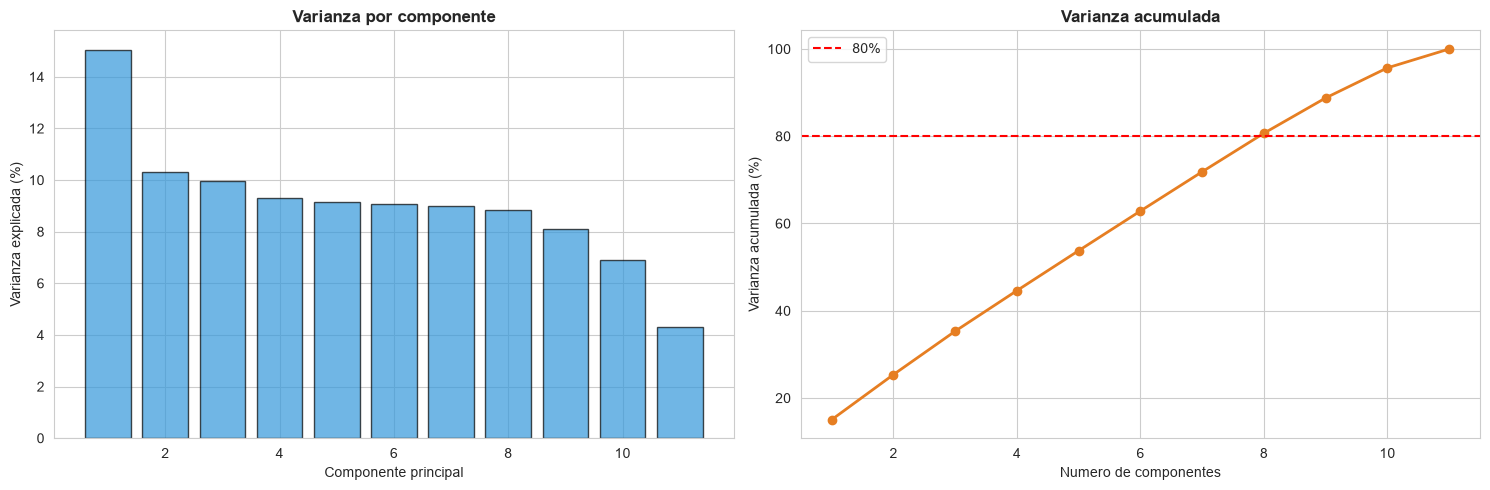

PC1: 15.0% (acumulado 15.0%)
PC2: 10.3% (acumulado 25.4%)
PC3: 10.0% (acumulado 35.3%)
PC4: 9.3% (acumulado 44.6%)
PC5: 9.2% (acumulado 53.8%)
PC6: 9.1% (acumulado 62.9%)
PC7: 9.0% (acumulado 71.9%)
PC8: 8.8% (acumulado 80.7%)
PC9: 8.1% (acumulado 88.8%)
PC10: 6.9% (acumulado 95.7%)
PC11: 4.3% (acumulado 100.0%)


In [14]:
# PCA con todos los componentes, para ver cuanta varianza explica cada uno
pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)
var_exp = pca_full.explained_variance_ratio_
var_cum = np.cumsum(var_exp)

# Grafico la varianza explicada
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].bar(range(1, len(var_exp)+1), var_exp*100, color='#3498db', alpha=0.7, edgecolor='black')
axes[0].set_xlabel('Componente principal')
axes[0].set_ylabel('Varianza explicada (%)')
axes[0].set_title('Varianza por componente', fontweight='bold')
axes[1].plot(range(1, len(var_cum)+1), var_cum*100, 'o-', color='#e67e22', linewidth=2)
axes[1].axhline(y=80, color='red', linestyle='--', label='80%')
axes[1].set_xlabel('Numero de componentes')
axes[1].set_ylabel('Varianza acumulada (%)')
axes[1].set_title('Varianza acumulada', fontweight='bold')
axes[1].legend()
plt.tight_layout()
plt.show()

for i, (v, c) in enumerate(zip(var_exp, var_cum), 1):
    print(f'PC{i}: {v*100:.1f}% (acumulado {c*100:.1f}%)')

**Qué encontré, y por qué es honesto reconocerlo:** La varianza está muy repartida entre los
componentes. El primer componente explica solo el 15 por ciento, y el segundo el 10 por ciento.
Juntos, los dos primeros suman apenas el 25 por ciento. Para llegar al 80 por ciento necesito ocho
componentes.

Esto tiene una interpretación clara: las variables de este dataset están poco correlacionadas
entre sí, cada una aporta información relativamente independiente. No hay unas pocas dimensiones
que dominen. Es lo contrario de lo que pasa cuando las variables están muy correlacionadas, donde
los primeros componentes capturan casi todo. La consecuencia práctica es que la visualización en
dos dimensiones que hago a continuación conserva solo el 25 por ciento de la información, así que
la interpreto con cautela.

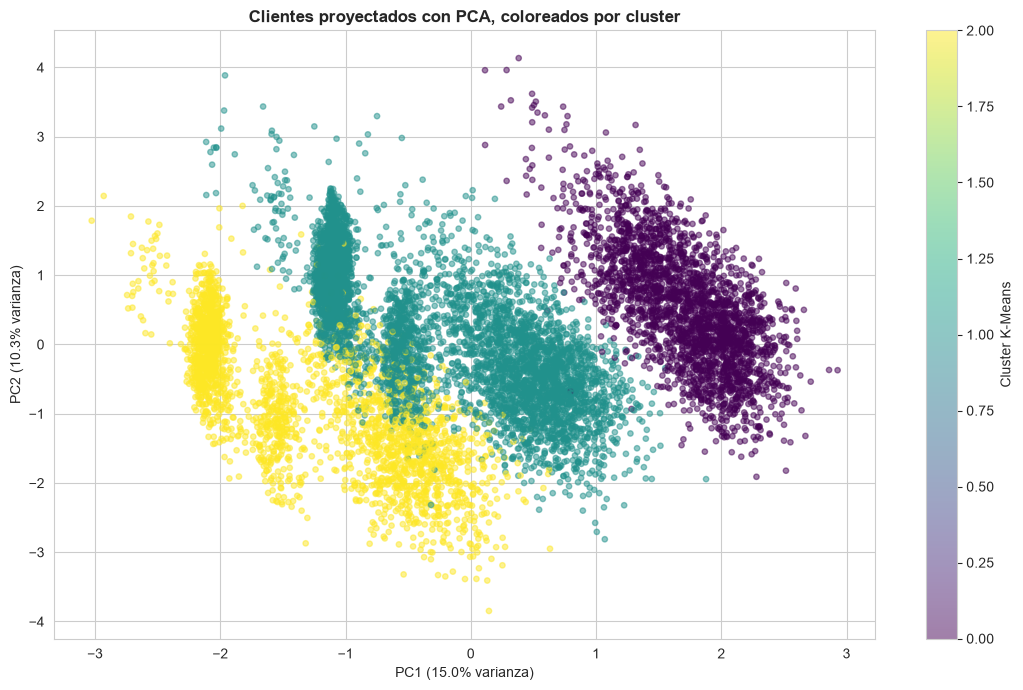

In [15]:
# Proyecto a 2 dimensiones para visualizar
pca_2d = PCA(n_components=2, random_state=42)
X_pca = pca_2d.fit_transform(X_scaled)

# Coloreo los puntos segun el cluster de K-Means
plt.figure(figsize=(11, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df_model['cluster'],
                      cmap='viridis', alpha=0.5, s=15)
plt.colorbar(scatter, label='Cluster K-Means')
plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% varianza)')
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% varianza)')
plt.title('Clientes proyectados con PCA, coloreados por cluster', fontweight='bold')
plt.tight_layout()
plt.show()

**Lectura del gráfico PCA:** A pesar de que solo capturo el 25 por ciento de la varianza, el
gráfico muestra que los tres clusters de K-Means ocupan zonas distinguibles del espacio. Se ven
tres regiones que se corresponden con los tres grupos, aunque con solapamiento en las fronteras.
El solapamiento es coherente con la silueta baja que vi antes: los grupos existen, pero no están
netamente separados. Esta visualización confirma que la segmentación tiene estructura, aunque
moderada.

## 9. t-SNE, Visualización No Lineal

t-SNE es otra técnica para visualizar datos de muchas dimensiones en dos, pero con un enfoque
distinto a PCA. Mientras PCA es lineal y preserva la estructura global, t-SNE es no lineal y se
enfoca en preservar la estructura local, es decir, en mantener juntos a los puntos que eran
vecinos en el espacio original.

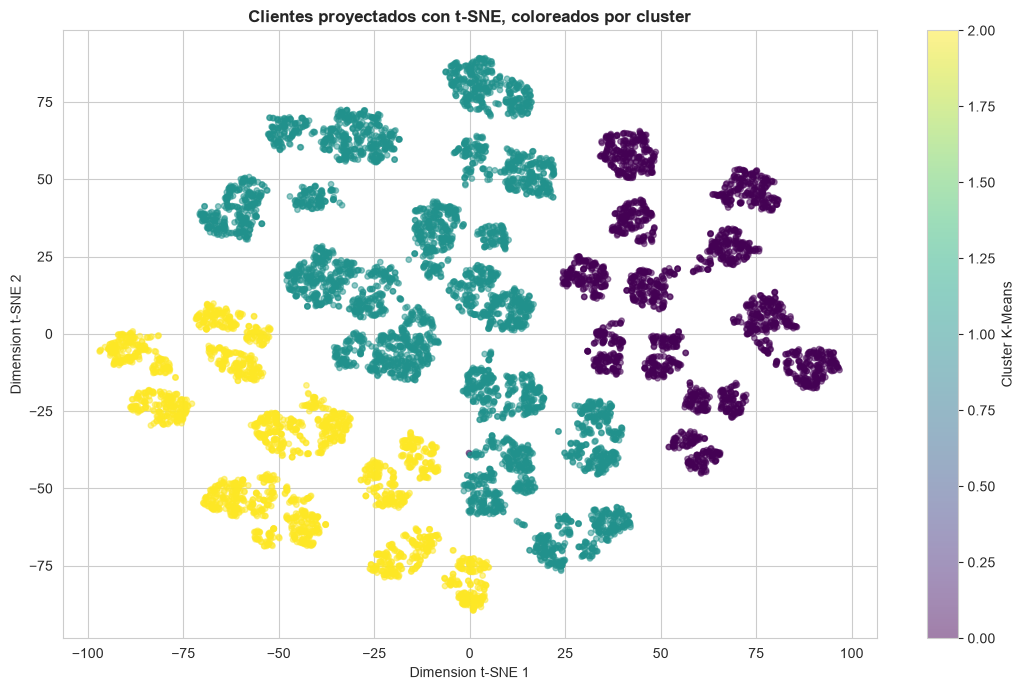

In [16]:
# t-SNE a 2 dimensiones. El parametro perplexity controla cuantos vecinos
# considera. Uso 30, un valor intermedio tipico.
# Nota: t-SNE es lento con muchos datos; puede tardar uno o dos minutos.
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

plt.figure(figsize=(11, 7))
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=df_model['cluster'],
                      cmap='viridis', alpha=0.5, s=15)
plt.colorbar(scatter, label='Cluster K-Means')
plt.xlabel('Dimension t-SNE 1')
plt.ylabel('Dimension t-SNE 2')
plt.title('Clientes proyectados con t-SNE, coloreados por cluster', fontweight='bold')
plt.tight_layout()
plt.show()

**Qué es el perplexity y cómo lo interpreto:** El perplexity es el parámetro principal de
t-SNE, y controla cuántos vecinos considera cada punto al armar la visualización. Un valor bajo,
de 5 a 10, se enfoca en vecinos muy cercanos y resalta la estructura local fina. Uno alto, de 40 a
50, considera un vecindario más amplio y da una vista más global. Uso 30, un valor intermedio y
estándar.

**Diferencias con PCA y precauciones:** t-SNE suele mostrar grupos más definidos y separados que
PCA, porque su objetivo es justamente agrupar visualmente a los vecinos. Pero tiene limitaciones
importantes que debo tener en cuenta. Sus ejes no tienen significado interpretable, a diferencia de
los componentes de PCA. Las distancias entre grupos en el gráfico no son fiables: que dos grupos se
vean lejos no significa que sean muy distintos. Y el tamaño de los grupos en el gráfico no refleja
su tamaño real. Por eso t-SNE sirve para explorar visualmente si hay estructura, pero no para sacar
conclusiones cuantitativas. En este caso, confirma visualmente que los clusters tienen cierta
separación.

## Features Derivadas del Clustering

Una aplicación práctica del clustering es convertir sus resultados en nuevas variables que
puedan alimentar a los modelos supervisados o a reglas de negocio. Creo dos features derivadas.

In [17]:
# Feature 1: la etiqueta de cluster de cada cliente.
# Puede usarse como variable categorica en un modelo supervisado.
df_model['cluster_kmeans'] = kmeans.labels_

# Feature 2: un ranking de riesgo del cluster, ordenado por su tasa de churn.
# 0 = segmento de mayor churn, 2 = segmento de menor churn.
# Esto vuelve la informacion independiente del numero arbitrario que asigna K-Means:
# sin importar que numero le toque a cada grupo, el ranking siempre refleja el riesgo.
churn_por_cluster = df_model.groupby('cluster_kmeans')['Exited'].mean().sort_values(ascending=False)
mapa_riesgo = {cluster: rango for rango, cluster in enumerate(churn_por_cluster.index)}
df_model['cluster_risk_rank'] = df_model['cluster_kmeans'].map(mapa_riesgo)

print('Features derivadas creadas:')
print()
print('Relacion cluster -> ranking de riesgo (0 = mayor churn):')
for cluster, rango in mapa_riesgo.items():
    churn = df_model[df_model['cluster_kmeans']==cluster]['Exited'].mean()*100
    print(f'  Cluster {cluster} -> risk_rank {rango} (churn {churn:.1f}%)')
print()
print(df_model[['cluster_kmeans', 'cluster_risk_rank', 'Exited']].head())

Features derivadas creadas:

Relacion cluster -> ranking de riesgo (0 = mayor churn):
  Cluster 0 -> risk_rank 0 (churn 32.4%)
  Cluster 2 -> risk_rank 1 (churn 16.7%)
  Cluster 1 -> risk_rank 2 (churn 16.2%)

   cluster_kmeans  cluster_risk_rank  Exited
0               1                  2       1
1               2                  1       0
2               1                  2       1
3               1                  2       0
4               2                  1       0


## 10. Conclusiones del Avance

Este avance aplicó aprendizaje no supervisado para segmentar a los clientes de FinanceGuard, y los
resultados aportan una visión complementaria a los modelos predictivos.

**El hallazgo central:** K-Means, sin usar la variable de churn, dividió a los clientes en tres
segmentos que resultaron corresponder a los tres países. Y al cruzar esos segmentos con el churn
real, el segmento alemán mostró una tasa del 32 por ciento, el doble de los otros dos. El
aprendizaje no supervisado encontró por su cuenta el mismo grupo de alto riesgo que los modelos
supervisados ya habían señalado, lo que refuerza la validez de ambos enfoques.

**Sobre las técnicas:** K-Means dio la segmentación más clara e interpretable, con un K igual a 3
elegido por el método del codo y la silueta. DBSCAN aportó la detección de clientes atípicos, útil
como complemento. PCA reveló que las variables están poco correlacionadas, ya que la varianza se
reparte entre muchos componentes, lo que limita la compresión pero es informativo por sí mismo.
t-SNE ofreció una visualización que confirma la estructura de los grupos.

**El valor para el negocio:** La segmentación le da al banco una forma de agrupar a sus clientes y
priorizar. El segmento alemán, con alto saldo y alto churn, es la prioridad de retención: son
clientes valiosos y en riesgo. Esta visión por segmentos complementa la predicción individual de
los avances anteriores, permitiendo diseñar estrategias dirigidas a grupos completos.

**Cierre del proyecto:** Con los modelos supervisados de los avances 1 y 2, y la segmentación no
supervisada de este avance, el proyecto ofrece a FinanceGuard una caja de herramientas completa
para entender y combatir el churn, tanto a nivel de cada cliente como de grupos, acercándolo a su
meta de reducir el abandono del veinte al quince por ciento.